# LLaMA-2-7B (2 Experiments)

## Overview
This notebook runs 2 experiments on LLaMA-2-7B (the model used in the scientific paper):
1. k-NN Word vs Non-word Classification
2. Single-Token Logit Lens

## Configuration
- **Seeds:** [42, 123] (2 seeds for more robustness)
- **Dataset:** WikiText-103 
- **Sample sizes:** 1000 (k-NN), 1000 (single-token)

## Part 1: Setup and Installation

In [ ]:
# Install required packages
!pip install -q datasets transformers accelerate scipy scikit-learn matplotlib pandas tqdm
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 42.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.8 MB/s eta 0:00:0000:01010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dep

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re
import random
from tqdm import tqdm
import pandas as pd
import gc
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"VRAM Free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4
VRAM: 15.8 GB
VRAM Free: 15.7 GB


## Part 2: Configuration

In [ ]:
# 2 seeds for more robustness 
SEEDS = [42, 123]

KNN_NUM_WORDS = 1000           
SINGLE_TOKEN_NUM_WORDS = 1000  
MULTI_TOKEN_NUM_WORDS = 200    
CONTEXT_LENGTH = 100          

# k-NN parameters 
K_NEIGHBORS = 4
MIN_TOKENS = 2
MAX_TOKENS = 4
TRAIN_TEST_SPLIT = 0.8

# Model configuration
PRIMARY_MODEL = "meta-llama/Llama-2-7b-hf"
FALLBACK_MODEL = "openlm-research/open_llama_3b"  # Same architecture family, fits in memory

print("Configuration:")
print(f"  Seeds: {SEEDS}")
print(f"  k-NN sample size: {KNN_NUM_WORDS}")
print(f"  Single-token sample size: {SINGLE_TOKEN_NUM_WORDS}")
print(f"  Multi-token sample size: {MULTI_TOKEN_NUM_WORDS}")
print(f"  Context length: {CONTEXT_LENGTH}")
print(f"  k neighbors: {K_NEIGHBORS}")
print(f"  Primary model: {PRIMARY_MODEL}")
print(f"  Fallback model: {FALLBACK_MODEL}")

Configuration:
  Seeds: [42, 123]
  k-NN sample size: 1000
  Single-token sample size: 1000
  Multi-token sample size: 200
  Context length: 100
  k neighbors: 4
  Primary model: meta-llama/Llama-2-7b-hf
  Fallback model: openlm-research/open_llama_3b


## Part 3: Hugging Face Login 

You need to:
1. Have a Hugging Face account
2. Accept the LLaMA-2 license at https://huggingface.co/meta-llama/Llama-2-7b-hf
3. Create an access token at https://huggingface.co/settings/tokens

In [ ]:
from huggingface_hub import login

login()

## Part 4: Load WikiText-103 Dataset

In [7]:
# Load WikiText-103 dataset
print("Loading WikiText-103 dataset...")
dataset = load_dataset("wikitext", "wikitext-103-v1", split="train")
print(f"Dataset loaded: {len(dataset)} examples")

Loading WikiText-103 dataset...


README.md: 0.00B [00:00, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Dataset loaded: 1801350 examples


## Part 5: Data Extraction Functions

In [ ]:
def extract_words_for_knn(dataset, tokenizer, num_words=1000, min_tokens=2, max_tokens=4):
    """
    Extract multi-token words for k-NN experiment:
    - Words that split into 2-4 tokens
    - Only alphabetic characters
    """
    words = []
    word_set = set()
    
    for example in tqdm(dataset, desc="Extracting k-NN words"):
        text = example['text'].strip()
        if text:
            raw_words = re.findall(r'\b[a-zA-Z]{4,}\b', text)
            for word in raw_words:
                word_lower = word.lower()
                if word_lower in word_set:
                    continue
                tokens = tokenizer.tokenize(word_lower)
                if min_tokens <= len(tokens) <= max_tokens:
                    if word_lower.isalpha():
                        word_set.add(word_lower)
                        words.append(word_lower)
                if len(words) >= num_words:
                    return words
    return words


def extract_single_token_words(dataset, tokenizer, num_words=1000):
    """
    Extract single-token words for Logit Lens experiment:
    - Single-token words from WikiText-103
    - Min 3 characters
    """
    words = []
    word_set = set()
    
    for example in tqdm(dataset, desc="Extracting single-token words"):
        text = example['text'].strip()
        if text:
            raw_words = re.findall(r'\b[a-zA-Z]{4,}\b', text)
            for word in raw_words:
                word_lower = word.lower()
                if word_lower in word_set:
                    continue
                tokens = tokenizer.encode(word_lower, add_special_tokens=False)
                # Single token only + alphabetic filter
                if len(tokens) == 1 and word_lower.isalpha():
                    word_set.add(word_lower)
                    words.append(word_lower)
                if len(words) >= num_words:
                    return words
    return words


def extract_multitoken_words(dataset, tokenizer, num_words=250):
    """
    Extract multi-token words for PatchScopes.
    - Use WikiText-103 
    - 200-500 words
    - Filter numerals
    """
    words = []
    word_set = set()
    
    for example in tqdm(dataset, desc="Extracting multi-token words"):
        text = example['text'].strip()
        if text:
            raw_words = re.findall(r'\b[a-zA-Z]{4,}\b', text)
            for word in raw_words:
                word_lower = word.lower()
                if word_lower in word_set:
                    continue
                tokens = tokenizer.encode(word_lower, add_special_tokens=False)
                # Multi-token (2+) and alphabetic only
                if len(tokens) >= 2 and word_lower.isalpha():
                    word_set.add(word_lower)
                    words.append(word_lower)
                if len(words) >= num_words:
                    return words
    return words


def generate_nonwords(words, tokenizer):
    """
    Generate non-words by shuffling tokens while preserving positions.
    """
    nonwords = []
    for word in words:
        tokens = tokenizer.tokenize(word)
        if len(tokens) >= 2:
            shuffled = tokens.copy()
            if len(tokens) == 2:
                shuffled = [tokens[1], tokens[0]]
            elif len(tokens) == 3:
                shuffled = [tokens[0], tokens[2], tokens[1]]
            else:
                middle = shuffled[1:-1]
                random.shuffle(middle)
                shuffled[1:-1] = middle
            nonword = tokenizer.convert_tokens_to_string(shuffled)
            nonwords.append(nonword)
    return nonwords

## Part 6: Model Loading with Memory Optimizations

### Optimization Strategy in Case of Failure during runtime:
1. **Primary:** 8-bit quantization
2. **If OOM:** 4-bit quantization
3. **Fallback:** OpenLLaMA-3B (same LLaMA architecture)

In [ ]:
def load_model_with_optimizations(model_name, quantization="8bit"):
    """
    Load model with memory optimizations.
    """
    print(f"Loading {model_name} with {quantization} quantization...")
    
    # Clear GPU memory first
    torch.cuda.empty_cache()
    gc.collect()
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    if quantization == "8bit":
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            load_in_8bit=True,
            device_map="auto",
            torch_dtype=torch.float16,
        )
    elif quantization == "4bit":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="auto",
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map="auto",
        )
    
    model.eval()
    
    print(f"Model loaded successfully!")
    print(f"  Layers: {model.config.num_hidden_layers}")
    print(f"  Hidden dim: {model.config.hidden_size}")
    if torch.cuda.is_available():
        print(f"  VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    
    return model, tokenizer


def try_load_model():
    """
    Try to load LLaMA-2-7B with progressive fallbacks.
    """
    try:
        print("\n" + "="*60)
        print("Attempt 1: LLaMA-2-7B with 8-bit quantization")
        print("="*60)
        model, tokenizer = load_model_with_optimizations(PRIMARY_MODEL, "8bit")
        return model, tokenizer, "LLaMA-2-7B (8-bit)"
    except Exception as e:
        print(f"Failed: {e}")
    
    try:
        print("\n" + "="*60)
        print("Attempt 2: LLaMA-2-7B with 4-bit quantization")
        print("="*60)
        torch.cuda.empty_cache()
        gc.collect()
        model, tokenizer = load_model_with_optimizations(PRIMARY_MODEL, "4bit")
        return model, tokenizer, "LLaMA-2-7B (4-bit)"
    except Exception as e:
        print(f"Failed: {e}")
    
    print("\n" + "="*60)
    print("Attempt 3: OpenLLaMA-3B (fallback - same LLaMA architecture)")
    print("="*60)
    print("Note: OpenLLaMA-3B uses the same LLaMA architecture as LLaMA-2-7B,")
    print("so results will demonstrate the same detokenization hypothesis.")
    torch.cuda.empty_cache()
    gc.collect()
    model, tokenizer = load_model_with_optimizations(FALLBACK_MODEL, "fp16")
    return model, tokenizer, "OpenLLaMA-3B (fallback)"

In [ ]:
model, tokenizer, model_name_used = try_load_model()
print(f"\n✓ Using model: {model_name_used}")


Attempt 1: LLaMA-2-7B with 8-bit quantization
Loading meta-llama/Llama-2-7b-hf with 8bit quantization...


tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Model loaded successfully!
  Layers: 32
  Hidden dim: 4096
  VRAM used: 3.10 GB

✓ Using model: LLaMA-2-7B (8-bit)


## Part 7: Hidden State Extraction

In [ ]:
def extract_hidden_states(texts, tokenizer, model, batch_size=1):
    """
    Extract last-token hidden states from all layers.
    """
    all_states = []
    
    for text in tqdm(texts, desc="Extracting hidden states"):
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        hidden_states = outputs.hidden_states[1:]
        last_token_states = []
        for hs in hidden_states:
            last_token_states.append(hs[0, -1, :].cpu().float().numpy())
        
        all_states.append(np.stack(last_token_states))
    
    return np.array(all_states)

## Part 8: Experiment 1 - k-NN Word vs Non-word Classification

In [ ]:
def run_knn_single_seed(word_states, nonword_states, seed):
    """
    Run k-NN classification for a single seed.
    Returns accuracy, precision, recall, F1 per layer.
    """
    np.random.seed(seed)
    
    X = np.concatenate([word_states, nonword_states], axis=0)
    y = np.array([0] * len(word_states) + [1] * len(nonword_states))
    
    num_samples, num_layers, hidden_dim = X.shape
    
    # Train/test split (80/20)
    train_idx, test_idx = train_test_split(
        np.arange(num_samples), test_size=1-TRAIN_TEST_SPLIT, random_state=seed
    )
    
    results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    for layer in range(num_layers):
        X_layer = X[:, layer, :]
        X_train, X_test = X_layer[train_idx], X_layer[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='euclidean')
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        results['accuracy'].append(accuracy_score(y_test, y_pred))
        results['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        results['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        results['f1'].append(f1_score(y_test, y_pred, zero_division=0))
    
    return results


def run_knn_with_seeds(word_states, nonword_states, seeds=SEEDS):
    """
    Run k-NN with multiple seeds and compute mean ± 95% CI.
    """
    all_results = {metric: [] for metric in ['accuracy', 'precision', 'recall', 'f1']}
    
    for seed in seeds:
        print(f"  Running k-NN with seed {seed}...")
        seed_results = run_knn_single_seed(word_states, nonword_states, seed)
        for metric in all_results:
            all_results[metric].append(seed_results[metric])
    
    final_results = {}
    for metric in all_results:
        data = np.array(all_results[metric]) 
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        ci_95 = 1.96 * std / np.sqrt(len(seeds))
        final_results[metric] = {'mean': mean, 'ci_95': ci_95, 'all_runs': data}
    
    return final_results

In [ ]:
# EXPERIMENT 1: k-NN Word vs Non-word
print("\n" + "="*60)
print(f"EXPERIMENT 1: k-NN Word vs Non-word ({model_name_used})")
print("="*60)

# Extract words
knn_words = extract_words_for_knn(dataset, tokenizer, KNN_NUM_WORDS)
print(f"Extracted {len(knn_words)} words")

# Generate non-words
knn_nonwords = generate_nonwords(knn_words, tokenizer)
print(f"Generated {len(knn_nonwords)} non-words")

print("\nExamples:")
for i in range(3):
    print(f"  Word: '{knn_words[i]}' -> Non-word: '{knn_nonwords[i]}'")


EXPERIMENT 1: k-NN Word vs Non-word (LLaMA-2-7B (8-bit))


Extracting k-NN words:   0%|          | 304/1801350 [00:00<18:46, 1598.45it/s]

Extracted 1000 words


Generated 1000 non-words

Examples:
  Word: 'valkyria' -> Non-word: 'valriaky'
  Word: 'chronicles' -> Non-word: 'icles chron'
  Word: 'japanese' -> Non-word: 'japesean'


In [15]:
# Extract hidden states
print("\nExtracting hidden states for words...")
word_states = extract_hidden_states(knn_words, tokenizer, model)
print(f"Word states shape: {word_states.shape}")

print("\nExtracting hidden states for non-words...")
nonword_states = extract_hidden_states(knn_nonwords, tokenizer, model)
print(f"Non-word states shape: {nonword_states.shape}")


Extracting hidden states for words...


Extracting hidden states: 100%|██████████| 1000/1000 [03:23<00:00,  4.91it/s]


Word states shape: (1000, 32, 4096)

Extracting hidden states for non-words...


Extracting hidden states: 100%|██████████| 1000/1000 [03:21<00:00,  4.96it/s]


Non-word states shape: (1000, 32, 4096)


In [16]:
# Run k-NN with 2 seeds
print(f"\nRunning k-NN classification with {len(SEEDS)} seeds...")
knn_results = run_knn_with_seeds(word_states, nonword_states, SEEDS)

# Print summary
peak_layer = np.argmax(knn_results['accuracy']['mean'])
peak_acc = knn_results['accuracy']['mean'][peak_layer]
peak_ci = knn_results['accuracy']['ci_95'][peak_layer]
print(f"\n✓ Peak accuracy: {peak_acc:.3f} ± {peak_ci:.3f} at layer {peak_layer}")


Running k-NN classification with 2 seeds...
  Running k-NN with seed 42...
  Running k-NN with seed 123...

✓ Peak accuracy: 0.971 ± 0.002 at layer 9


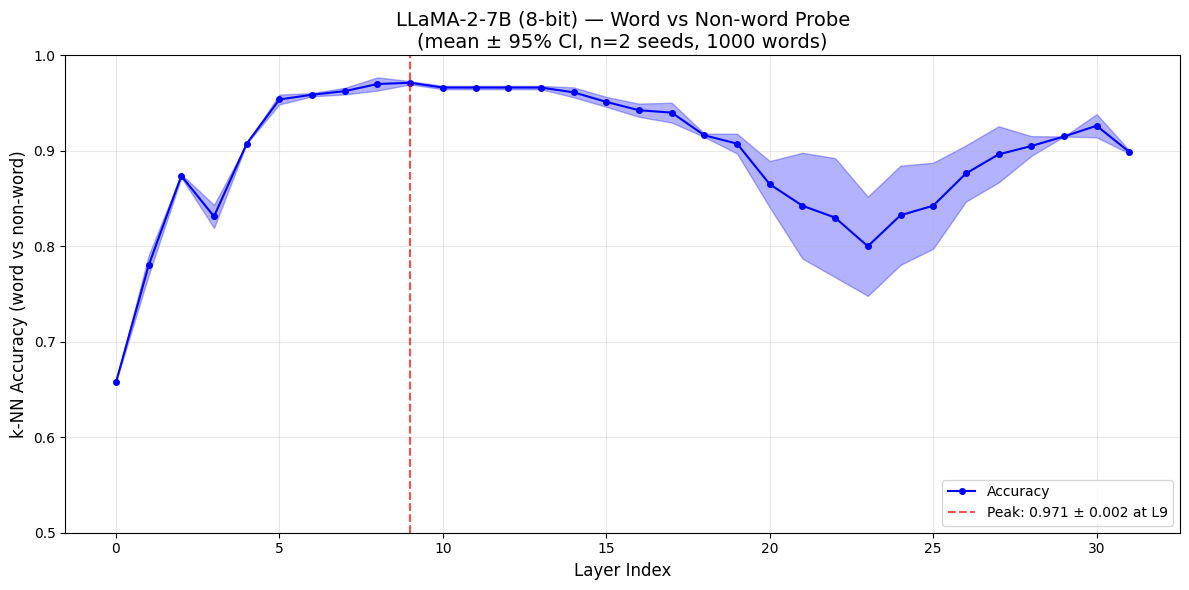


Saved: knn_results.png


In [ ]:
# Plot k-NN results
fig, ax = plt.subplots(figsize=(12, 6))

layers = np.arange(len(knn_results['accuracy']['mean']))
mean = knn_results['accuracy']['mean']
ci = knn_results['accuracy']['ci_95']

ax.plot(layers, mean, 'b-', marker='o', markersize=4, label='Accuracy')
ax.fill_between(layers, mean - ci, mean + ci, alpha=0.3, color='blue')

ax.axvline(x=peak_layer, color='r', linestyle='--', alpha=0.7, 
           label=f'Peak: {peak_acc:.3f} ± {peak_ci:.3f} at L{peak_layer}')

ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('k-NN Accuracy (word vs non-word)', fontsize=12)
ax.set_title(f'{model_name_used} — Word vs Non-word Probe\n(mean ± 95% CI, n={len(SEEDS)} seeds, {len(knn_words)} words)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig('knn_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: knn_results.png")

## Part 9: Experiment 2 - Single-Token Logit Lens

In [ ]:
def artificial_split(word, n_parts=None):
    """
    Artificially split a single-token word into multiple character chunks.
    """
    if len(word) < 3:
        return [word]
    
    if n_parts is None:
        n_parts = random.randint(2, min(5, len(word)))
    
    # Calculate chunk size
    chunk_size = max(1, len(word) // n_parts)
    
    parts = []
    for i in range(0, len(word), chunk_size):
        part = word[i:i+chunk_size]
        if part:
            parts.append(part)
    
    return parts


def run_logit_lens_single_seed(words, model, tokenizer, context_text, seed, max_words=500):
    """
    Run logit lens experiment for single-token words with artificial splitting.
    - Use INPUT embedding matrix
    - Feed model the new sequence of tokens preceded by context
    - Check if last token's hidden state maps to the original single-token word
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Get input embedding matrix
    embedding_matrix = model.get_input_embeddings().weight.data.cpu().float()
    
    num_layers = model.config.num_hidden_layers + 1
    retrieval_per_layer = [0] * num_layers
    total_words = 0
    skipped_ineffective_splits = 0
    
    context_ids = tokenizer.encode(context_text, add_special_tokens=False)[-CONTEXT_LENGTH:]
    
    for word in tqdm(words[:max_words], desc=f"Logit Lens (seed {seed})"):
        original_tokens = tokenizer.encode(word, add_special_tokens=False)
        if len(original_tokens) != 1:
            continue
        original_token_id = original_tokens[0]
        
        # Artificially split the word into character chunks
        parts = artificial_split(word)
        
        split_token_ids = []
        for part in parts:
            # Each part like "ca" or "ts" gets tokenized independently
            part_tokens = tokenizer.encode(part, add_special_tokens=False)
            split_token_ids.extend(part_tokens)
        
        if len(split_token_ids) <= 1:
            skipped_ineffective_splits += 1
            continue
        
        input_ids = context_ids + split_token_ids
        input_ids_tensor = torch.tensor([input_ids]).to(model.device)
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids_tensor, output_hidden_states=True)
        
        # Check each layer
        for layer_idx, hidden_state in enumerate(outputs.hidden_states):
            if layer_idx >= num_layers:
                break
            
            # Get last token's hidden state
            last_token_hs = hidden_state[0, -1, :].cpu().float()
            
            # Cosine similarity with input embedding matrix
            last_token_norm = last_token_hs / (last_token_hs.norm() + 1e-8)
            embed_norm = embedding_matrix / (embedding_matrix.norm(dim=1, keepdim=True) + 1e-8)
            similarities = torch.matmul(embed_norm, last_token_norm)
            
            closest_idx = similarities.argmax().item()
            
            if closest_idx == original_token_id:
                retrieval_per_layer[layer_idx] += 1
        
        total_words += 1
    
    # Convert to rates
    retrieval_rates = [count / total_words if total_words > 0 else 0 
                       for count in retrieval_per_layer]
    
    print(f"  Processed {total_words} words (skipped {skipped_ineffective_splits} ineffective splits)")
    print(f"  Peak retrieval: {max(retrieval_rates):.3f} at layer {retrieval_rates.index(max(retrieval_rates))}")
    
    return retrieval_rates


def run_logit_lens_with_seeds(words, model, tokenizer, dataset, seeds=SEEDS):
    """Run logit lens with multiple seeds and compute mean with 95% CI."""
    
    # Get context once
    context_text = get_context_from_dataset(dataset, tokenizer, CONTEXT_LENGTH)
    print(f"Context: {len(context_text)} characters, ~{CONTEXT_LENGTH} tokens")
    
    all_results = []
    
    for seed in seeds:
        print(f"\nRunning Logit Lens with seed {seed}...")
        results = run_logit_lens_single_seed(words, model, tokenizer, context_text, seed)
        all_results.append(results)
    
    # Calculate statistics
    data = np.array(all_results)
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci_95 = 1.96 * std / np.sqrt(len(seeds))
    
    return {'mean': mean, 'ci_95': ci_95, 'all_runs': data}

In [ ]:
# EXPERIMENT 2: Single-Token Logit Lens
print("\n" + "="*60)
print(f"EXPERIMENT 2: Single-Token Logit Lens ({model_name_used})")
print("="*60)

# Extract single-token words
single_words = extract_single_token_words(dataset, tokenizer, SINGLE_TOKEN_NUM_WORDS)
print(f"Extracted {len(single_words)} single-token words")
print(f"Examples: {single_words[:10]}")


EXPERIMENT 2: Single-Token Logit Lens (LLaMA-2-7B (8-bit))


Extracting single-token words:   0%|          | 118/1801350 [00:00<17:49, 1683.83it/s]

Extracted 1000 single-token words
Examples: ['commonly', 'referred', 'outside', 'role', 'playing', 'video', 'game', 'developed', 'media', 'vision']


In [24]:
# Run logit lens with 2 seeds
print(f"\nRunning Logit Lens with {len(SEEDS)} seeds...")
logit_results = run_logit_lens_with_seeds(single_words, model, tokenizer, dataset, SEEDS)

# Print summary
peak_layer = np.argmax(logit_results['mean'])
peak_rate = logit_results['mean'][peak_layer]
peak_ci = logit_results['ci_95'][peak_layer]
print(f"\n✓ Peak retrieval rate: {peak_rate:.3f} ± {peak_ci:.3f} at layer {peak_layer}")


Running Logit Lens with 2 seeds...
Context: 317 characters, ~100 tokens

Running Logit Lens with seed 42...


Logit Lens (seed 42): 100%|██████████| 500/500 [1:15:40<00:00,  9.08s/it]


  Processed 500 words (skipped 0 ineffective splits)
  Peak retrieval: 0.478 at layer 16

Running Logit Lens with seed 123...


Logit Lens (seed 123): 100%|██████████| 500/500 [1:15:53<00:00,  9.11s/it]

  Processed 500 words (skipped 0 ineffective splits)
  Peak retrieval: 0.510 at layer 16

✓ Peak retrieval rate: 0.494 ± 0.022 at layer 16


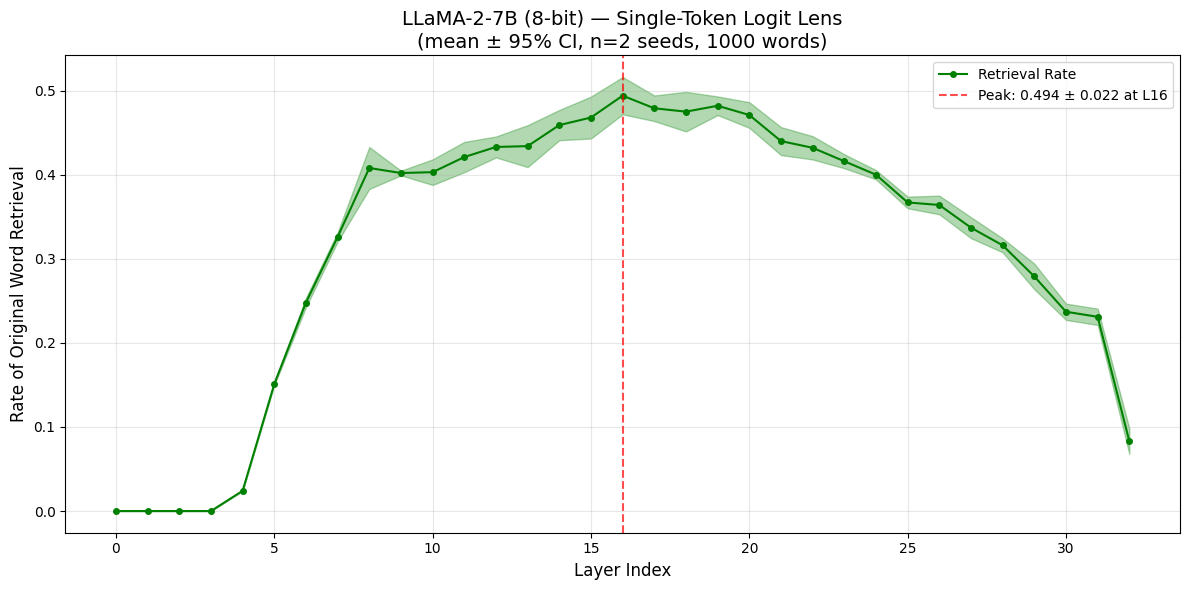


Saved: logit_lens_results.png


In [25]:
# Plot logit lens results
fig, ax = plt.subplots(figsize=(12, 6))

layers = np.arange(len(logit_results['mean']))
mean = logit_results['mean']
ci = logit_results['ci_95']

ax.plot(layers, mean, 'g-', marker='o', markersize=4, label='Retrieval Rate')
ax.fill_between(layers, mean - ci, mean + ci, alpha=0.3, color='green')

# Mark peak
ax.axvline(x=peak_layer, color='r', linestyle='--', alpha=0.7,
           label=f'Peak: {peak_rate:.3f} ± {peak_ci:.3f} at L{peak_layer}')

ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Rate of Original Word Retrieval', fontsize=12)
ax.set_title(f'{model_name_used} — Single-Token Logit Lens\n(mean ± 95% CI, n={len(SEEDS)} seeds, {len(single_words)} words)', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logit_lens_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logit_lens_results.png")